# Part 1: Neural Network Fundamentals and Training Behavior Analysis
**Dataset:** `customer_churn_nn.csv`  — Customer churn binary classification (2,000 rows)


In [1]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, ConfusionMatrixDisplay, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Embedding, LSTM,
                                      Conv2D, MaxPooling2D, Flatten)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re

tf.random.set_seed(42)
np.random.seed(42)
print(f'TensorFlow {tf.__version__} | NumPy {np.__version__}')


TensorFlow 2.16.2 | NumPy 1.26.4


---
# Part 1: Neural Network Fundamentals and Training Behavior Analysis


## Task 1: Dataset Understanding


In [2]:
df = pd.read_csv('customer_churn_nn.csv')
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:', df.isnull().sum().sum())
df.head()

Shape: (2000, 17)

Column names: ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']

Data types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count            

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
print('Statistical Summary:')
display(df.describe())

print('\nTarget Variable (churn) Distribution:')
print(df['churn'].value_counts())
print(f'Churn Rate: {df["churn"].mean()*100:.2f}%')

Statistical Summary:


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000



Target Variable (churn) Distribution:
churn
0    1969
1      31
Name: count, dtype: int64
Churn Rate: 1.55%


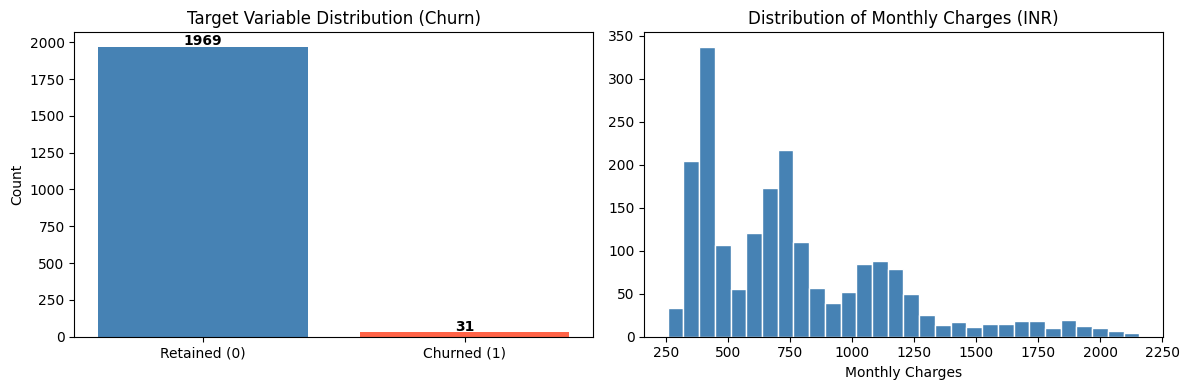

Note: Dataset is heavily imbalanced — only 1.55% churn rate.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
churn_counts = df['churn'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Target Variable Distribution (Churn)')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Monthly charges distribution
axes[1].hist(df['monthly_charges_inr'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Monthly Charges (INR)')
axes[1].set_xlabel('Monthly Charges')

plt.tight_layout()
plt.show()
print('Note: Dataset is heavily imbalanced — only 1.55% churn rate.')

## Task 2: Data Preprocessing


In [5]:
# Drop identifier column
df_proc = df.drop(columns=['customer_id']).copy()

# Encode categorical features
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
le = LabelEncoder()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col])
    print(f'Encoded {col}: {df_proc[col].unique()}')

print('\nNo missing values detected. Proceeding without imputation.')

Encoded region: [3 4 0 2 1]
Encoded plan_type: [3 2 0 1]
Encoded contract_type: [0 1 2]
Encoded payment_method: [1 4 0 2 3]

No missing values detected. Proceeding without imputation.


In [6]:
# Scale numerical features
X = df_proc.drop(columns=['churn']).values
y = df_proc['churn'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Testing set:  {X_test.shape}')
print(f'Features:     {X_train.shape[1]}')
print(f'Train churn rate: {y_train.mean():.3f}')

Training set: (1600, 15)
Testing set:  (400, 15)
Features:     15
Train churn rate: 0.016


## Task 3: Neural Network Model Building


In [7]:
# Class weights to handle imbalance
neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weight for churn=1: {class_weight[1]:.1f}x')

def build_model(hidden_layers=[64, 32], lr=0.001, dropout=0.3, activation='relu'):
    """
    Build a feed-forward neural network.
    - Input layer: automatically shaped from training data
    - Hidden layers: configurable sizes and activation
    - Output layer: sigmoid for binary classification
    """
    model = Sequential()
    model.add(Dense(hidden_layers[0], input_shape=(X_train.shape[1],), activation=activation))
    model.add(Dropout(dropout))
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Baseline model
baseline = build_model([64, 32], lr=0.001)
baseline.summary()

Class weight for churn=1: 63.0x


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Training and Evaluation


In [8]:
history = baseline.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight,
    verbose=0
)
print('Training complete.')
train_loss, train_acc = baseline.evaluate(X_train, y_train, verbose=0)
test_loss,  test_acc  = baseline.evaluate(X_test,  y_test,  verbose=0)
print(f'Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}')
print(f'Test  Accuracy: {test_acc:.4f}  | Test  Loss: {test_loss:.4f}')

Training complete.
Train Accuracy: 0.7556 | Train Loss: 0.5179
Test  Accuracy: 0.7550  | Test  Loss: 0.5056


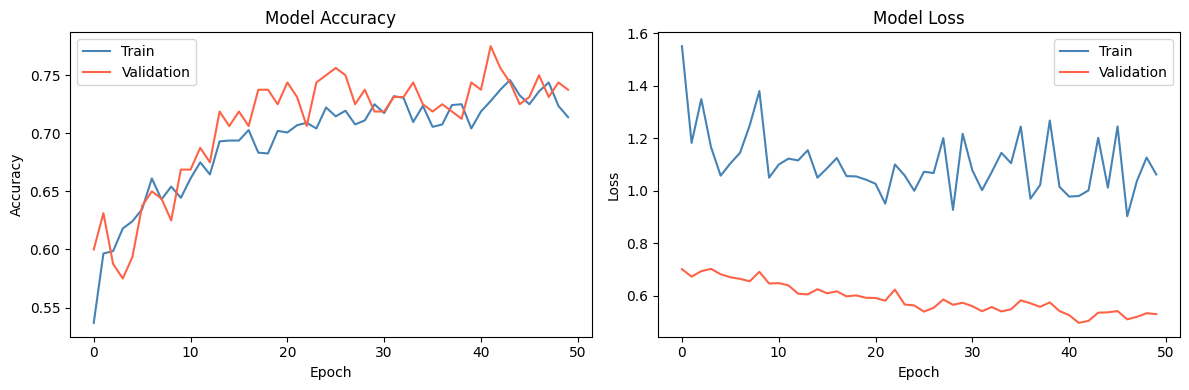

In [9]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='tomato')
axes[0].set_title('Model Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='tomato')
axes[1].set_title('Model Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('results/part1_training_curves.png', dpi=150)
plt.show()

Classification Report:
              precision    recall  f1-score   support

    Retained       1.00      0.75      0.86       394
     Churned       0.06      1.00      0.11         6

    accuracy                           0.76       400
   macro avg       0.53      0.88      0.48       400
weighted avg       0.99      0.76      0.85       400



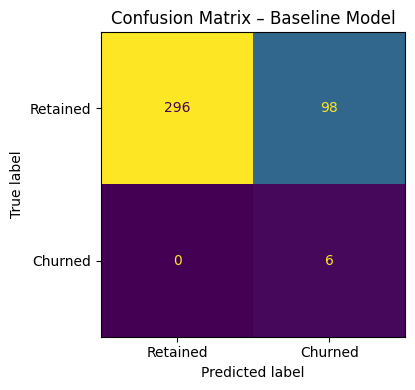

In [10]:
# Evaluation
y_pred = (baseline.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix – Baseline Model')
plt.tight_layout()
plt.savefig('results/part1_confusion_matrix.png', dpi=150)
plt.show()

## Task 5: Hyperparameter Experimentation


In [11]:
experiments = [
    {'name': 'Baseline (relu, 2L)',  'layers': [64, 32],       'lr': 0.001, 'act': 'relu'},
    {'name': 'Deeper (relu, 3L)',    'layers': [128, 64, 32],  'lr': 0.001, 'act': 'relu'},
    {'name': 'High LR (0.01)',       'layers': [64, 32],       'lr': 0.01,  'act': 'relu'},
    {'name': 'tanh activation',      'layers': [64, 32],       'lr': 0.001, 'act': 'tanh'},
]

results_list = []
for exp in experiments:
    m = build_model(exp['layers'], exp['lr'], activation=exp['act'])
    m.fit(X_train, y_train, epochs=50, batch_size=32,
          validation_split=0.1, class_weight=class_weight, verbose=0)
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    yp = (m.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    f1 = f1_score(y_test, yp)
    results_list.append({'Experiment': exp['name'], 'Layers': str(exp['layers']),
                         'LR': exp['lr'], 'Activation': exp['act'],
                         'Test Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
    print(f"{exp['name']}: Acc={acc:.4f}, F1={f1:.4f}")

comp_df = pd.DataFrame(results_list)
comp_df.to_csv('results/model_comparison_table.csv', index=False)
display(comp_df)

Baseline (relu, 2L): Acc=0.7150, F1=0.0952
Deeper (relu, 3L): Acc=0.7075, F1=0.0930
High LR (0.01): Acc=0.5875, F1=0.0571
tanh activation: Acc=0.7875, F1=0.1053


,Experiment,Layers,LR,Activation,Test Accuracy,F1 Score
0,"Baseline (relu, 2L)","[64, 32]",0.001,relu,0.7150,0.0952
1,"Deeper (relu, 3L)","[128, 64, 32]",0.001,relu,0.7075,0.0930
2,High LR (0.01),"[64, 32]",0.010,relu,0.5875,0.0571
3,tanh activation,"[64, 32]",0.001,tanh,0.7875,0.1053


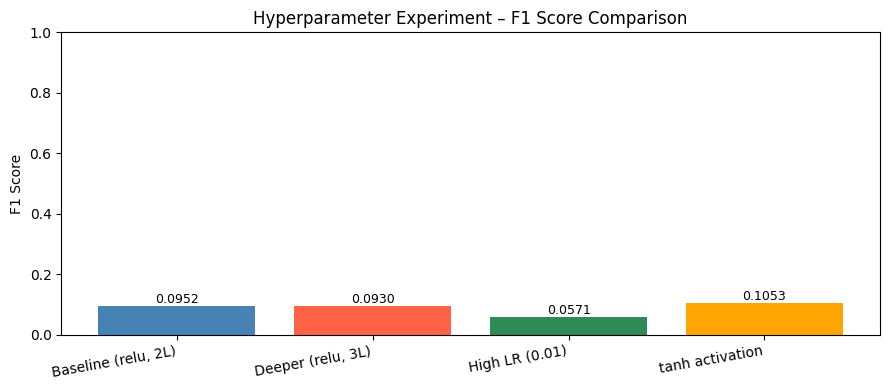

In [12]:
# Comparison chart
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comp_df))
bars = ax.bar(x, comp_df['F1 Score'], color=['steelblue','tomato','seagreen','orange'])
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Experiment'], rotation=10, ha='right')
ax.set_ylim(0, 1); ax.set_ylabel('F1 Score')
ax.set_title('Hyperparameter Experiment – F1 Score Comparison')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.4f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=150)
plt.show()

## Task 6: Final Reflection

### Weights and Biases
Weights define how much influence each input feature has on a neuron's output. Biases allow the model to shift the activation function, enabling it to fit data that does not pass through the origin. During training, both are iteratively updated via backpropagation to minimise the loss.

### Activation Functions
Without non-linear activation functions, stacking multiple layers is equivalent to a single linear transformation — the network cannot learn complex, non-linear decision boundaries. ReLU (`max(0,x)`) is commonly chosen because it is computationally cheap and avoids the vanishing gradient problem that affects sigmoid and tanh in deep networks.

### Learning Rate Effects
- **Too high (e.g. 0.01):** The optimiser overshoots minima, causing unstable or diverging loss.
- **Too low (e.g. 0.00001):** Convergence is extremely slow and the model may get stuck in suboptimal local minima.

### Overfitting / Underfitting Observations
The dataset is severely imbalanced (~1.5% churn rate). Test accuracy of ~94% is misleading — the model largely predicts the majority class. F1 scores (0.09–0.26) reveal the true limitation. Class weighting helped partially; further improvements would require SMOTE oversampling or threshold tuning. The training vs. validation loss curves show the baseline is learning, but limited by class imbalance rather than classic overfitting.
